In [ ]:
import pandas as pd
import re

# 1 Dataset Overview

In [ ]:
# read csv file
df_netflix = pd.read_csv('netflix_titles.csv')
df_netflix
# Nan represnt null values

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
# data types
df_netflix.dtypes

# duration, date_added are object so it's somewhat weird

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
# shape of dataframe
df_netflix.shape

(8807, 12)

# 2 Identify missing Data

In [ ]:
# number of rows missing in each column
df_netflix.isnull() # gives true false for null(missing) values
df_netflix.isnull().sum().sort_values(ascending = False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [ ]:
# now we the top columns in the above table are the best candidate to drop as they have large number of null values
# so we have to verify the percentage of these mnull values represent from the total rows

In [ ]:
# % of rows missing in this column
for column in df_netflix.columns:
  p = df_netflix[column].isnull().mean()*100
  print(column + ": " + str(round(p,2))+" %")

show_id: 0.0 %
type: 0.0 %
title: 0.0 %
director: 29.91 %
cast: 9.37 %
country: 9.44 %
date_added: 0.11 %
release_year: 0.0 %
rating: 0.05 %
duration: 0.03 %
listed_in: 0.0 %
description: 0.0 %


# 3 Dealing with missing data


In [ ]:
# Remove a column or row with .drop, .dropna or .isnull
# drop column
df_netflix.drop('director', axis=1)

# drop row M1
# no_director = df_netflix[df_netflix['director'].isnull()].index
# df_netflix.drop(no_director, axis=0)

# drop row M2
# no_duration = df_netflix[df_netflix['duration'].isnull()].index
# df_netflix.drop(no_duration, axis=0, inplace=True)

# ~ + .isnull() M3
# df_netflix[~df_netflix['director'].isnull()]

# dropna() M4
df_netflix.dropna(subset = ['director'])

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
df_netflix[df_netflix['rating'].isnull()] # 4 null values in rating

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [ ]:
# use fillna() to replace NAN by the mean, median (numeric data) or mode (categorical data) (= most common value inside a column)
mode = ''.join(df_netflix['rating'].mode()) # convert it to string (as it's series) and then use join method to join the
type(mode) # str
# could also used mean or median if it was numeric data but here we have categorical data in ratings so we used mode

df_netflix['rating'].fillna(mode, inplace = True)

/tmp/ipykernel_1123/2282809570.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_netflix['rating'].fillna(mode, inplace = True)


In [ ]:
df_netflix.isnull().mean() # 0 null values for rating column

,0
show_id,0.000000
type,0.000000
title,0.000000
director,0.299080
cast,0.093675
country,0.094357
date_added,0.001135
release_year,0.000000
rating,0.000000
duration,0.000341


In [ ]:
# Replace it by an arbitary number with .fillna() (arbitary number doesnt affect final result)
df_netflix['duration'].fillna('0', inplace = True)

# backward
# df_netflix.fillna(method = 'bfill')
# forward
df_netflix.fillna(method = 'ffill')

/tmp/ipykernel_1123/1523003346.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_netflix['duration'].fillna('0', inplace = True)
/tmp/ipykernel_1123/1523003346.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_netflix.fillna(method = 'ffill')


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Kirsten Johnson,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",South Africa,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",South Africa,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Julien Leclercq,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [ ]:
# Extracting data from "duration" column with split() and extract() method
df_movies = df_netflix[df_netflix['type'] == 'Movie']

df_movies['minute'] = df_movies['duration'].str.split(expand = True)[0].astype(int)


/tmp/ipykernel_1123/967563471.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['minute'] = df_movies['duration'].str.split(expand = True)[0].astype(int)


In [ ]:
# df_netflix['date_added'].str.split(',', expand = True)[1]
df_netflix['date_added'].str.extract('(\d{4})')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1123/518214084.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_netflix['date_added'].str.extract('(\d{4})')


,0
0,2021
1,2021
2,2021
3,2021
4,2021
...,...
8802,2019
8803,2019
8804,2019
8805,2020


# 4 Identifying Outliers

## 4.1 Using Histograms to identify outliers within numeric data

<Axes: ylabel='Frequency'>

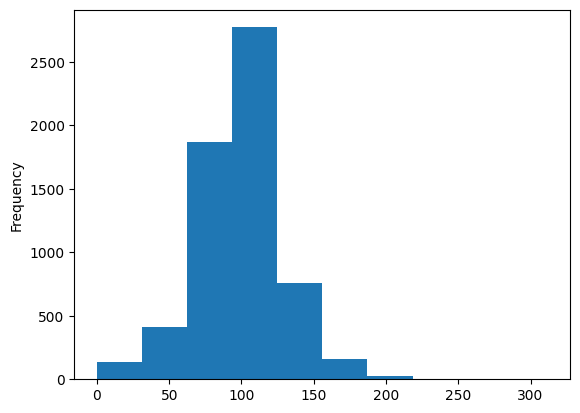

In [ ]:
# make histogram with pandas
df_movies['minute'].plot(kind = 'hist', bins = 10)

In [ ]:
# get bar ranges with value_count method and number of bins
df_movies['minute'].value_counts(bins = 10).sort_index()

,count
"(-0.313, 31.2]",135
"(31.2, 62.4]",410
"(62.4, 93.6]",1867
"(93.6, 124.8]",2772
"(124.8, 156.0]",766
"(156.0, 187.2]",150
"(187.2, 218.4]",22
"(218.4, 249.6]",6
"(249.6, 280.8]",2
"(280.8, 312.0]",1


In [ ]:
# dealing with outliers
df_movies[(df_movies['minute'] > 31) & (df_movies['minute'] < 218)] # removed outliers
df_movies[~((df_movies['minute'] > 31) & (df_movies['minute'] < 218))] # outliers

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
45,s46,Movie,My Heroes Were Cowboys,Tyler Greco,NaN,NaN,"September 16, 2021",2021,PG,23 min,Documentaries,Robin Wiltshire's painful childhood was rescue...,23
71,s72,Movie,A StoryBots Space Adventure,David A. Vargas,"Evan Spiridellis, Erin Fitzgerald, Jeff Gill, ...",NaN,"September 14, 2021",2021,TV-Y,13 min,Children & Family Movies,Join the StoryBots and the space travelers of ...,13
166,s167,Movie,Once Upon a Time in America,Sergio Leone,"Robert De Niro, James Woods, Elizabeth McGover...","Italy, United States","September 1, 2021",1984,R,229 min,"Classic Movies, Dramas",Director Sergio Leone's sprawling crime epic f...,229
694,s695,Movie,Aziza,Soudade Kaadan,"Caress Bashar, Abdel Moneim Amayri","Lebanon, Syria","June 17, 2021",2019,TV-PG,13 min,"Comedies, Dramas, Independent Movies",This short film follows a newly displaced Syri...,13
695,s696,Movie,Besieged Bread,Soudade Kaadan,"Lama Hakeim, Gabriel Malki, Ehab Shaaban",NaN,"June 17, 2021",2015,TV-14,12 min,"Dramas, International Movies","In battle-ridden Syria, a woman trying to smug...",12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7788,s7789,Movie,Power Rangers: Megaforce: The Robo Knight Befo...,James Barr,"Andrew M. Gray, Ciara Hanna, John Mark Louderm...",United States,"January 1, 2016",2013,TV-Y7,24 min,Children & Family Movies,Robo Knight learns the meaning of Christmas fr...,24
7848,s7849,Movie,Refugee,"Clementine Malpas, Leslie Knott","Cate Blanchett, Lynsey Addario, Omar Victor Di...",NaN,"March 10, 2017",2016,TV-PG,24 min,Documentaries,Five acclaimed photographers travel the world ...,24
7891,s7892,Movie,Room on the Broom,"Max Lang, Jani Lachauer","Simon Pegg, Gillian Anderson, Rob Brydon, Mart...","United Kingdom, Germany","July 1, 2019",2012,TV-Y7,26 min,"Children & Family Movies, Independent Movies",A gentle witch with a ginger braid offers ride...,26
7932,s7933,Movie,Sangam,Raj Kapoor,"Raj Kapoor, Vyjayanthimala, Rajendra Kumar, La...",India,"December 31, 2019",1964,TV-14,228 min,"Classic Movies, Dramas, International Movies",Returning home from war after being assumed de...,228


## 4.2 Using Boxplot to identify outliers within numeric data  

<Axes: >

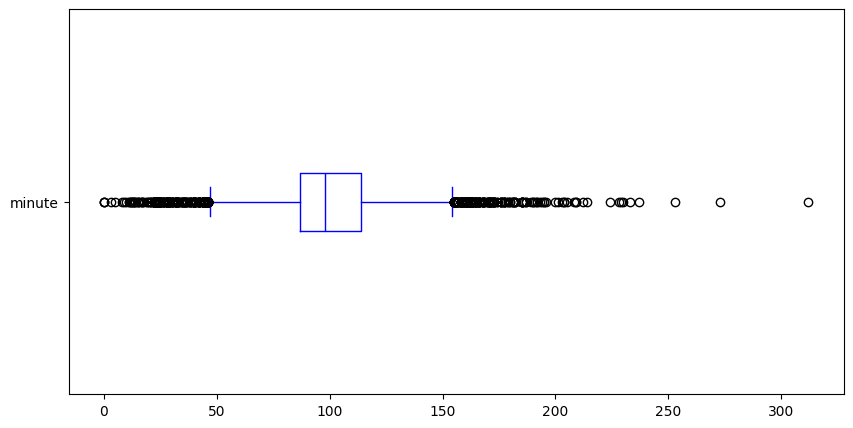

In [ ]:
# make a boxplot with pandas
df_movies['minute'].plot(kind = 'box', vert = False, color = 'blue', figsize = (10,5))

In [ ]:
# overview descriptive statistics
IQR = 114.000000 - 87.000000 # IQR = Q3- Q1
min_boxplot = 87.000000 - 1.5 * IQR # Q1 - 1.5 * IQR
max_boxplot = 114.000000 + 1.5 * IQR# Q3 + 1.5 * IQR

print(min_boxplot, max_boxplot)

#df_movies['minute'].describe()

46.5 154.5


In [ ]:
# dealing with outliers
df_movies[(df_movies['minute'] > 46.5) & (df_movies['minute'] < 154.5)] # removed outliers
df_movies[~((df_movies['minute'] > 46.5) & (df_movies['minute'] < 154.5))] # outliers

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...,161
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...,166
45,s46,Movie,My Heroes Were Cowboys,Tyler Greco,NaN,NaN,"September 16, 2021",2021,PG,23 min,Documentaries,Robin Wiltshire's painful childhood was rescue...,23
71,s72,Movie,A StoryBots Space Adventure,David A. Vargas,"Evan Spiridellis, Erin Fitzgerald, Jeff Gill, ...",NaN,"September 14, 2021",2021,TV-Y,13 min,Children & Family Movies,Join the StoryBots and the space travelers of ...,13
73,s74,Movie,King of Boys,Kemi Adetiba,"Sola Sobowale, Adesua Etomi, Remilekun ""Remini...",Nigeria,"September 14, 2021",2018,TV-MA,182 min,"Dramas, International Movies",When a powerful businesswoman’s political ambi...,182
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...,45
8764,s8765,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,"January 1, 2020",1994,PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...,191
8770,s8771,Movie,Yaadein,Subhash Ghai,"Jackie Shroff, Hrithik Roshan, Kareena Kapoor,...",India,"March 1, 2018",2001,TV-14,171 min,"Dramas, International Movies, Romantic Movies",Two young lovers set out to overcome the obsta...,171
8788,s8789,Movie,You Carry Me,Ivona Juka,"Lana Baric, Vojislav Brajovic, Natasa Janjic, ...","Croatia, Slovenia, Serbia, Montenegro","July 1, 2016",2015,TV-MA,157 min,"Dramas, International Movies","A soap opera producer, director and makeup art...",157


# 4.3 Using Bars to identify outliers within categorical data

<Axes: xlabel='rating'>

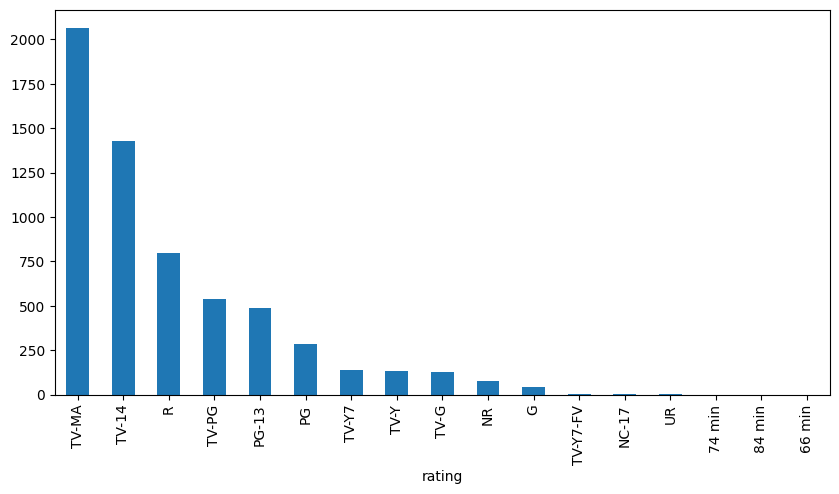

In [ ]:
# make barplot with pandas
df_movies['rating'].value_counts().plot(kind = 'bar', figsize = (10,5))

In [ ]:
# dealing with outliers
df_movies[~(df_movies['rating'].isin(['TV-Y7-FV', 'NC-17', 'UR', '74 min', '84 min','66 min']))] # removed outliers
df_movies[(df_movies['rating'].isin(['TV-Y7-FV', 'NC-17', 'UR', '74 min', '84 min','66 min']))] # outliers

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
5264,s5265,Movie,Swearnet: The Movie,Warren P. Sonoda,"Mike Smith, John Paul Tremblay, Robb Wells, Pa...",Canada,"September 24, 2017",2014,NC-17,112 min,"Comedies, International Movies","After losing a TV network deal, the Trailer Pa...",112
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,0,Movies,"Louis C.K. muses on religion, eternal love, gi...",0
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,0,Movies,Emmy-winning comedy writer Louis C.K. brings h...,0
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,0,Movies,The comic puts his trademark hilarious/thought...,0
6338,s6339,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain","August 26, 2016",2013,NC-17,180 min,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ...",180
6581,s6582,Movie,Dear Dracula,Chad Van De Keere,"Nathan Gamble, Ray Liotta, Emilio Estevez, Ari...",United States,"February 18, 2016",2012,TV-Y7-FV,43 min,"Children & Family Movies, Comedies",When he gets a fan letter from a young monster...,43
7058,s7059,Movie,Immoral Tales,Walerian Borowczyk,"Lise Danvers, Fabrice Luchini, Charlotte Alexa...",France,"June 6, 2019",1974,UR,103 min,"Dramas, International Movies, Romantic Movies",This anthology illustrates the timeless nature...,103
7263,s7264,Movie,Lady-Like,NaN,"Allie Gallerani, Beverly D'Angelo, Olivia Lucc...",United States,"January 18, 2019",2018,NC-17,83 min,"Comedies, Independent Movies",After she pushes her best friend Kort to date ...,83
7290,s7291,Movie,LEGO Ninjago: Masters of Spinjitzu: Day of the...,NaN,NaN,"Denmark, China","February 1, 2019",2016,TV-Y7-FV,44 min,"Action & Adventure, Children & Family Movies",Cole finds himself trapped in Yang's temple af...,44
7292,s7293,Movie,Leo the Lion,Mario Cambi,"Daniel Amerman, John Cygan, Matthew Mercer, Am...","United States, Italy","December 20, 2015",2013,TV-Y7-FV,78 min,"Children & Family Movies, Comedies",Eschewing the carnivorous ways of his fellow l...,78


# 5 Text Normalization

## 5.1 Dealing inconsistent capitalization: lower(), upper(), title()

In [ ]:
# change the case of text with str attributes
# df_movies['title'].str.lower()
# df_movies['title'].str.upper()
# df_movies['title'].str.title()

# update values
# df_movies['title'] = df_movies['title'].str.upper()


# change the case of text with apply method (no need to access str attribute)
df_movies['title'] = df_movies['title'].apply(lambda x: x.title())
df_movies

/tmp/ipykernel_1123/103028128.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['title'] = df_movies['title'].apply(lambda x: x.title())


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,minute
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,96
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88


## 5.2 Remove blank spaces with strip(), lstrip(), and rstrip()

In [ ]:
# how the strip() method works
movie_title = ' Titanic   '

# trim leading space with lstrip()
movie_title.lstrip()
# trim trailing space with rstrip()
movie_title.rstrip()
# trim leading and trailing space with strip()
movie_title.strip()

'Titanic'

In [ ]:
# get rid of leading and trailing white spaces with strip() method
# df_movies['title'] = df_movies['title'].str.strip()


# get rid of leading and trailing white spaces with apply method
df_movies['title'] = df_movies['title'].apply(lambda x: x.strip())
df_movies['title']

/tmp/ipykernel_1123/87094121.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['title'] = df_movies['title'].apply(lambda x: x.strip())


,title
0,Dick Johnson Is Dead
6,My Little Pony: A New Generation
7,Sankofa
9,The Starling
12,Je Suis Karl
...,...
8801,Zinzana
8802,Zodiac
8804,Zombieland
8805,Zoom


## 5.3 Replace string with replace() or sub() method


* \w -> a-z A-Z 0-9 _
* \s -> whitespaces

\w\s

In [ ]:
# remove punctuation signs with the str.replace() method and regex
df_movies['title'].str.replace('[^\w\s]','', regex = True)

# remove punctuation signs with the replace() method and regex
df_movies['title'].replace('[^\w\s]','', regex = True)

# difference between str.replace() and .replace()
df_movies['title'].str.replace(1,2) # will throw error as works for string datatype only(.str)
df_movies['title'].replace(1,2) # works with any datatype

# remove punctuation sign with re.sub() function via the apply() method
df_movies['title'].apply(lambda x: re.sub('[^\w\s]', '', x))

<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:12: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_1123/18651035.py:12: SyntaxWarning: invalid escape sequence '\w'
  df_movies['title'].apply(lambda x: re.sub('[^\w\s]', '', x))


,title
0,Dick Johnson Is Dead
6,My Little Pony A New Generation
7,Sankofa
9,The Starling
12,Je Suis Karl
...,...
8801,Zinzana
8802,Zodiac
8804,Zombieland
8805,Zoom
